In [27]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense,Dropout)

In [28]:
df = pd.read_csv("/content/diabetes.csv")

In [29]:
df.sample(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
115,4,146,92.0,32,169.5,31.2,0.539,61,1
529,0,111,65.0,27,102.5,24.6,0.660,31,0
140,3,128,78.0,27,102.5,21.1,0.268,55,0
670,6,165,68.0,26,168.0,33.6,0.631,49,0
466,0,74,52.0,10,36.0,27.8,0.269,22,0


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


In [31]:
!pip install -q -U keras-tuner

In [32]:
X = df.drop("Outcome",axis=1)
y = df["Outcome"]

In [33]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [34]:
X_train,X_test,y_train,y_test = train_test_split(X_scaled,y,test_size=0.25,random_state=1)

In [35]:
import kerastuner as klt

In [36]:
def build_model(hp):

    model = Sequential()

    counter = 0

    for i in range(hp.Int("num_layers", min_value=1, max_value=10)):

        if counter == 0:
            model.add(
                Dense(
                    hp.Int("units" + str(i), min_value=8, max_value=312, step=1),
                    activation = hp.Choice("activation" + str(i), values=["relu", "sigmoid", "tanh"]),
                    input_dim=8
                )
            )
            model.add(Dropout(hp.Choice("dropout_rate_" + str(i), values=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])))

        else:
            model.add(
                Dense(
                    hp.Int("units" + str(i), min_value=8, max_value=312, step=1),
                    activation=hp.Choice("activation" + str(i), values=["relu", "sigmoid", "tanh"])
                )
            )
            model.add(Dropout(hp.Choice("dropout_rate_" + str(i), values=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])))

        counter += 1

    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=hp.Choice(
            "optimizer", values=["adam", "sgd", "rmsprop", "adadelta"]
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [37]:
tuner = klt.RandomSearch(build_model,
                        objective='val_accuracy',
                        max_trials=3)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [38]:
tuner.search(X_train,y_train,epochs=5,validation_data=(X_test,y_test))

Trial 3 Complete [00h 00m 02s]
val_accuracy: 0.796875

Best val_accuracy So Far: 0.796875
Total elapsed time: 00h 00m 11s


In [40]:
tuner.get_best_hyperparameters()[0].values

{'num_layers': 1,
 'units0': 267,
 'activation0': 'relu',
 'dropout_rate_0': 0.8,
 'optimizer': 'sgd',
 'units1': 282,
 'activation1': 'tanh',
 'dropout_rate_1': 0.6,
 'units2': 31,
 'activation2': 'relu',
 'dropout_rate_2': 0.5,
 'units3': 49,
 'activation3': 'relu',
 'dropout_rate_3': 0.5,
 'units4': 85,
 'activation4': 'sigmoid',
 'dropout_rate_4': 0.4,
 'units5': 197,
 'activation5': 'relu',
 'dropout_rate_5': 0.3,
 'units6': 288,
 'activation6': 'relu',
 'dropout_rate_6': 0.7,
 'units7': 15,
 'activation7': 'relu',
 'dropout_rate_7': 0.2}

In [41]:
model = tuner.get_best_models(num_models=1)[0]

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [44]:
history = model.fit(X_train,y_train,epochs=200,initial_epoch=6,validation_data=(X_test,y_test))

Epoch 7/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8455 - loss: 0.3686 - val_accuracy: 0.8750 - val_loss: 0.3306
Epoch 8/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8247 - loss: 0.3878 - val_accuracy: 0.8750 - val_loss: 0.3308
Epoch 9/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8750 - loss: 0.3663 - val_accuracy: 0.8750 - val_loss: 0.3305
Epoch 10/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8524 - loss: 0.3704 - val_accuracy: 0.8750 - val_loss: 0.3304
Epoch 11/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8576 - loss: 0.3551 - val_accuracy: 0.8750 - val_loss: 0.3302
Epoch 12/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8507 - loss: 0.3676 - val_accuracy: 0.8750 - val_loss: 0.3298
Epoch 13/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8559 - loss: 0.3600 - val_accuracy: 0.8750 - val_loss: 0.3293
Epoch 14/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8333 - loss: 0.3846 - val_accuracy: 0.87

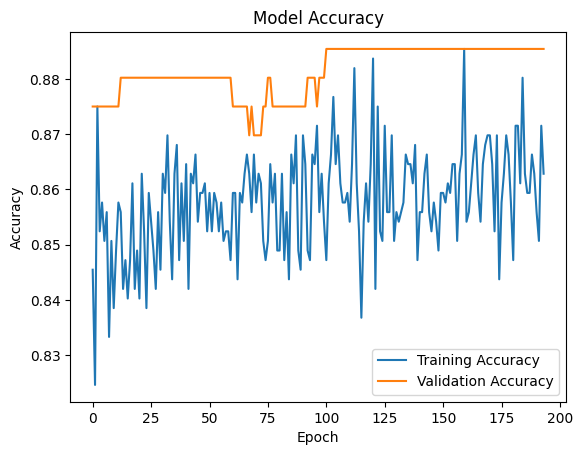

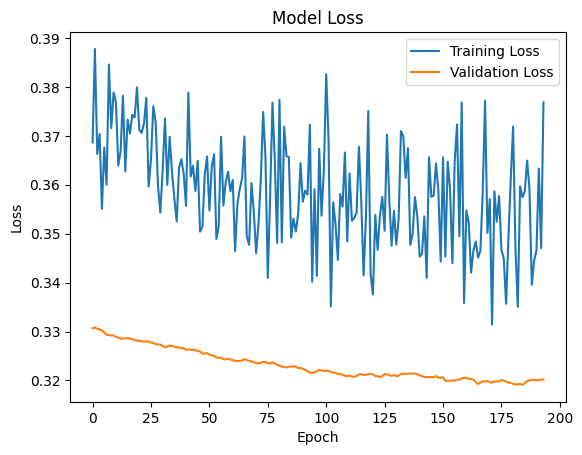

In [46]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()